# 🦴 Bone Fracture Classification — 2-Cell 초고속 버전
**CELL 1**: 설치 + Drive 마운트  
**CELL 2**: 데이터 로드 → 학습 → 평가 → 시각화 (⚡ 1분 이내)

In [1]:
# ============================================================
# CELL 1: 설치 & Google Drive 마운트
# ============================================================
!pip install -q timm seaborn

from google.colab import drive
drive.mount('/content/drive')
print('✅ 준비 완료 → CELL 2 실행하세요!')

Mounted at /content/drive
✅ 준비 완료 → CELL 2 실행하세요!


⚡ Device: cuda  |  출력: /content/drive/MyDrive/2026_lecture/Medical_AI/1week/output/fast_20260310_074942
✅ 10개 클래스 / 총 500장 로드


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

🧠 MobileNetV2  |  파라미터: 2.2M

🚀 학습 시작!
Epoch 1/3 | Train 13.0% | Val 2.0%  ⭐ Best!
Epoch 2/3 | Train 25.8% | Val 4.0%  ⭐ Best!
Epoch 3/3 | Train 36.0% | Val 14.0%  ⭐ Best!

✅ 학습 완료! 소요: 94.5초  |  Best Val: 14.0%


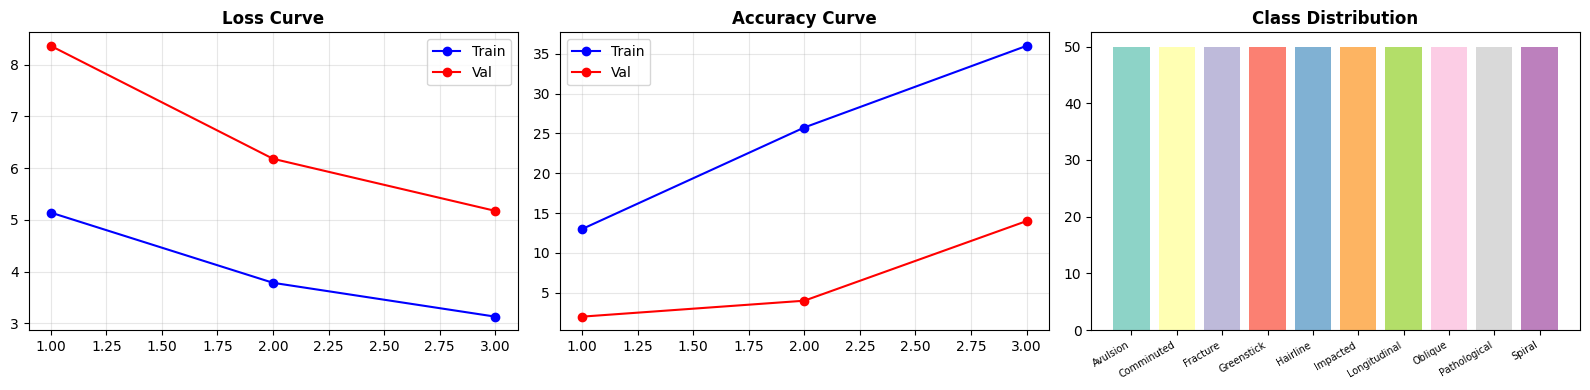

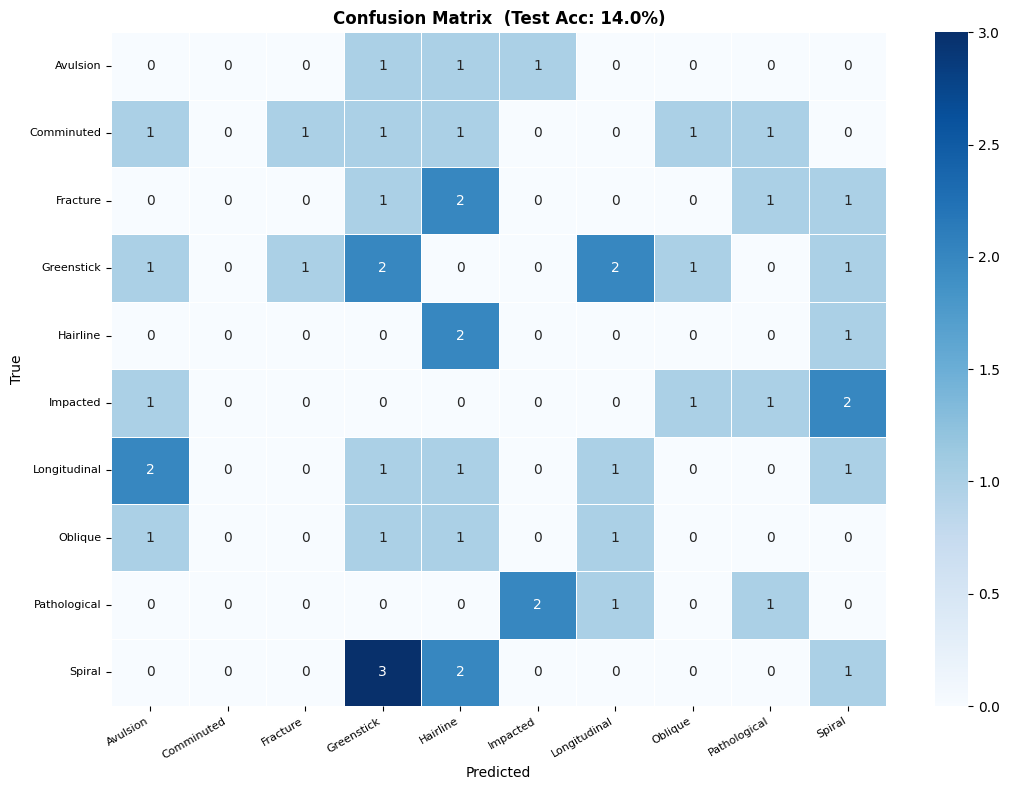

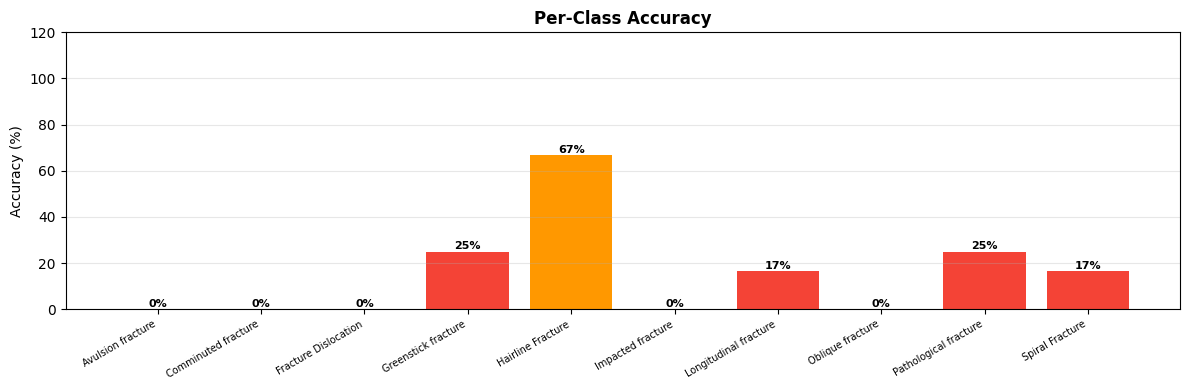


📋 Classification Report
                       precision    recall  f1-score   support

    Avulsion fracture      0.000     0.000     0.000         3
  Comminuted fracture      0.000     0.000     0.000         6
 Fracture Dislocation      0.000     0.000     0.000         5
  Greenstick fracture      0.200     0.250     0.222         8
    Hairline Fracture      0.200     0.667     0.308         3
    Impacted fracture      0.000     0.000     0.000         5
Longitudinal fracture      0.200     0.167     0.182         6
     Oblique fracture      0.000     0.000     0.000         4
Pathological fracture      0.250     0.250     0.250         4
      Spiral Fracture      0.143     0.167     0.154         6

             accuracy                          0.140        50
            macro avg      0.099     0.150     0.112        50
         weighted avg      0.105     0.140     0.114        50

  🎉 완료!
  ✅ Best Val Acc : 14.0%
  ✅ Test Acc     : 14.0%
  ⏱️  총 소요시간  : 113.9초
  📂 출력 경로

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
# ============================================================
# CELL 2: 전체 파이프라인 (데이터→학습→평가→시각화)
# ⚠️ INPUT_PATH 만 본인 경로로 수정하세요!
# ============================================================
import os, pathlib, time, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms
import timm
from sklearn.metrics import confusion_matrix, classification_report

# ── ⚙️ 설정 (여기만 수정!) ────────────────────────────────
INPUT_PATH     = "/content/drive/MyDrive/2026_lecture/Medical_AI/Medical_Imagining/Bone Break Classification"
OUTPUT_BASE    = "/content/drive/MyDrive/2026_lecture/Medical_AI/1week/output"
IMG_SIZE       = 96          # 해상도 (96=빠름 / 224=정확)
MAX_PER_CLASS  = 50          # 클래스당 최대 이미지 수
EPOCHS         = 3           # 학습 에포크
BATCH          = 64
LR             = 3e-4
# ─────────────────────────────────────────────────────────

IMG_EXTS = {'.png','.jpg','.jpeg','.bmp','.tiff','.tif','.webp'}
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
STAMP    = datetime.now().strftime('%Y%m%d_%H%M%S')
OUT      = os.path.join(OUTPUT_BASE, f'fast_{STAMP}')
os.makedirs(OUT, exist_ok=True)
torch.manual_seed(42); np.random.seed(42)
print(f'⚡ Device: {DEVICE}  |  출력: {OUT}')

# ── 1. 클래스 & 샘플 목록 수집 ────────────────────────────
class_names = sorted([d for d in os.listdir(INPUT_PATH)
                      if os.path.isdir(os.path.join(INPUT_PATH, d))])
samples = []  # (경로, 레이블)
class_counts = {}
sample_imgs  = {}
for i, cls in enumerate(class_names):
    imgs = [f for f in pathlib.Path(INPUT_PATH, cls).rglob('*')
            if f.suffix.lower() in IMG_EXTS][:MAX_PER_CLASS]
    class_counts[cls] = len(imgs)
    if imgs: sample_imgs[cls] = str(imgs[0])
    samples += [(str(p), i) for p in imgs]
np.random.shuffle(samples)
print(f'✅ {len(class_names)}개 클래스 / 총 {len(samples)}장 로드')

# ── 2. Dataset ────────────────────────────────────────────
t_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
v_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class SimpleDS(Dataset):
    def __init__(self, samples, tf): self.s, self.tf = samples, tf
    def __len__(self): return len(self.s)
    def __getitem__(self, i):
        img = Image.open(self.s[i][0]).convert('RGB')
        return self.tf(img), self.s[i][1]

n = len(samples)
n_tr = int(n*0.8); n_va = int(n*0.1)
tr_s, va_s, te_s = samples[:n_tr], samples[n_tr:n_tr+n_va], samples[n_tr+n_va:]

# WeightedSampler
lbls    = [s[1] for s in tr_s]
cnt     = np.array([lbls.count(i) for i in range(len(class_names))])
w       = 1.0 / np.maximum(cnt, 1)
sw      = torch.tensor([w[l] for l in lbls], dtype=torch.float)
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

tr_ld = DataLoader(SimpleDS(tr_s, t_tf), batch_size=BATCH, sampler=sampler, num_workers=2)
va_ld = DataLoader(SimpleDS(va_s, v_tf), batch_size=BATCH, shuffle=False, num_workers=2)
te_ld = DataLoader(SimpleDS(te_s, v_tf), batch_size=BATCH, shuffle=False, num_workers=2)

# ── 3. 모델 / 손실함수 / 옵티마이저 ───────────────────────
model     = timm.create_model('mobilenetv2_100', pretrained=True,
                               num_classes=len(class_names)).to(DEVICE)
cw        = torch.tensor(w/w.sum()*len(class_names), dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
print(f'🧠 MobileNetV2  |  파라미터: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

# ── 4. 학습 루프 ──────────────────────────────────────────
hist = {'tl':[],'vl':[],'ta':[],'va':[]}
best_acc, best_ckpt = 0.0, os.path.join(OUT, 'best_model.pth')
t0 = time.time()
print('\n🚀 학습 시작!'); print('='*60)

for ep in range(1, EPOCHS+1):
    # Train
    model.train()
    tl, tc, tt = 0., 0, 0
    for x, y in tr_ld:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tl += loss.item()*x.size(0); tc += (out.argmax(1)==y).sum().item(); tt += x.size(0)
    # Val
    model.eval(); vl, vc, vt = 0., 0, 0
    with torch.no_grad():
        for x, y in va_ld:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            vl  += criterion(out, y).item()*x.size(0)
            vc  += (out.argmax(1)==y).sum().item(); vt += x.size(0)
    tl/=tt; vl/=vt; ta=tc/tt*100; va=vc/vt*100
    hist['tl'].append(tl); hist['vl'].append(vl)
    hist['ta'].append(ta); hist['va'].append(va)
    scheduler.step()
    flag = ''
    if va > best_acc:
        best_acc = va
        torch.save({'model_state_dict': model.state_dict(),
                    'class_names': class_names}, best_ckpt)
        flag = '  ⭐ Best!'
    print(f'Epoch {ep}/{EPOCHS} | Train {ta:.1f}% | Val {va:.1f}%{flag}')

print(f'\n✅ 학습 완료! 소요: {time.time()-t0:.1f}초  |  Best Val: {best_acc:.1f}%')

# ── 5. 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss & Accuracy 곡선
ep_r = range(1, EPOCHS+1)
axes[0].plot(ep_r, hist['tl'], 'b-o', label='Train'); axes[0].plot(ep_r, hist['vl'], 'r-o', label='Val')
axes[0].set_title('Loss Curve', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep_r, hist['ta'], 'b-o', label='Train'); axes[1].plot(ep_r, hist['va'], 'r-o', label='Val')
axes[1].set_title('Accuracy Curve', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

# 클래스 분포
axes[2].bar(range(len(class_names)), [class_counts[c] for c in class_names],
            color=plt.cm.Set3.colors[:len(class_names)])
axes[2].set_xticks(range(len(class_names)))
axes[2].set_xticklabels([c.split()[0] for c in class_names], rotation=30, ha='right', fontsize=7)
axes[2].set_title('Class Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT, '01_curves.png'), dpi=120, bbox_inches='tight'); plt.show()

# ── 6. 테스트 평가 ────────────────────────────────────────
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE)['model_state_dict'])
model.eval()
preds, labs = [], []
with torch.no_grad():
    for x, y in te_ld:
        out = model(x.to(DEVICE))
        preds.extend(out.argmax(1).cpu().numpy()); labs.extend(y.numpy())
preds, labs = np.array(preds), np.array(labs)
test_acc = (preds == labs).mean() * 100

# Confusion Matrix
cm = confusion_matrix(labs, preds)
short = [c.split()[0] for c in class_names]
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short, yticklabels=short, ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix  (Test Acc: {test_acc:.1f}%)', fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT, '02_confusion_matrix.png'), dpi=120, bbox_inches='tight'); plt.show()

# Per-Class Accuracy
pca    = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['#4CAF50' if a>=70 else '#FF9800' if a>=40 else '#F44336' for a in pca]
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(len(class_names)), pca, color=colors)
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=7)
ax.set_ylim(0, 120); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy', fontweight='bold'); ax.grid(axis='y', alpha=0.3)
for bar, a in zip(bars, pca):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{a:.0f}%', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT, '03_per_class_acc.png'), dpi=120, bbox_inches='tight'); plt.show()

# ── 7. 최종 요약 ──────────────────────────────────────────
report = classification_report(labs, preds, target_names=class_names, digits=3)
print('\n📋 Classification Report'); print(report)

print(f'{'='*55}')
print(f'  🎉 완료!')
print(f'  ✅ Best Val Acc : {best_acc:.1f}%')
print(f'  ✅ Test Acc     : {test_acc:.1f}%')
print(f'  ⏱️  총 소요시간  : {time.time()-t0:.1f}초')
print(f'  📂 출력 경로    : {OUT}')
print(f'{'='*55}')